<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
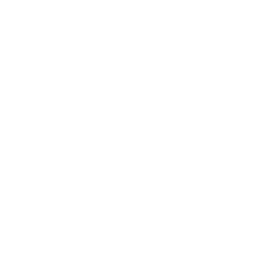
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Σχεδιασμός Split-Plot για Βελτιστοποίηση Διεργασίας</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Κατασκευή / Μηχανική Ποιότητας &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Αυτό το σημειωματάριο αναλύει ένα πείραμα σχεδιασμού split-plot για μια διεργασία
έγχυσης πλαστικού (injection molding). Ο παράγοντας του κύριου τεμαχίου (whole-plot)
είναι το **μηχάνημα** (4 επίπεδα: MACH_A-MACH_D), το οποίο είναι δύσκολο να
αλλάξει, και ο παράγοντας του υποτεμαχίου (sub-plot) είναι η **ρύθμιση
ταχύτητας** (5 επίπεδα: 60, 80, 100, 120, 140 RPM), η οποία αλλάζει εύκολα.
Λαμβάνονται πέντε επαναληπτικές μετρήσεις σε κάθε συνδυασμό μηχανήματος x
ταχύτητας, δίνοντας 100 παρατηρήσεις ποσοστού ελαττωμάτων.

Η `PROC MIXED` προσαρμόζει σωστά τη δομή περιορισμένης τυχαιοποίησης
αντιμετωπίζοντας το **μηχάνημα ως τυχαία επίδραση** (το στρώμα σφάλματος
του κύριου τεμαχίου) και την **ταχύτητα ως σταθερή επίδραση** (τον παράγοντα
του υποτεμαχίου). Η ανάλυση εκτιμά τις δύο συνιστώσες διακύμανσης, ελέγχει
την επίδραση της ταχύτητας και παράγει προσαρμοσμένες κατά Tukey ανά ζεύγη
συγκρίσεις των ελαχίστων τετραγωνικών μέσων (LS-means) της ταχύτητας για τον
εντοπισμό της ταχύτητας λειτουργίας που ελαχιστοποιεί το ποσοστό ελαττωμάτων.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Δεδομένα πειράματος split-plot: 4 μηχανήματα x 5 ταχύτητες x 5 επαναλήψεις | 100 |

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών δεδομένων χυτευτικής διεργασίας split-plot
   4 μηχανήματα (κύριο τεμάχιο) x 5 ταχύτητες (υποτεμάχιο) x 5 επαναλήψεις
   Επιπλέον επαναλήψεις για κάθε κύριο τεμάχιο
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.molding_experiment;
    CALL streaminit(42);
    ARRAY machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    ARRAY speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Πραγματικές επιδράσεις μηχανήματος (τυχαίες) */
    ARRAY mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Πραγματικές επιδράσεις ταχύτητας (σταθερές, τετραγωνικές με βέλτιστο ~100) */
    ARRAY speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    ΕΠΑΝΑΛΗΨΗ whole_plot = 1 ΕΩΣ 5;
        ΕΠΑΝΑΛΗΨΗ m = 1 ΕΩΣ 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* Επίδραση επανάληψης κύριου τεμαχίου */
            wp_noise = rand('normal', 0, 1.5);
            ΕΠΑΝΑΛΗΨΗ s = 1 ΕΩΣ 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* Επαναλήψεις υποτεμαχίου εντός κάθε κύριου τεμαχίου */
                ΕΠΑΝΑΛΗΨΗ rep = 1 ΕΩΣ 5;
                    obs_id + 1;
                    /* Ποσοστό ελαττωμάτων: σταθερά + μηχάνημα + ταχύτητα + αλληλεπίδραση + θόρυβος */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    ΕΑΝ defect_rate < 0 ΤΟΤΕ defect_rate = 0.01;
                    /* Δευτερεύουσα απόκριση: αντοχή σε εφελκυσμό */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    ΕΞΟΔΟΣ;
                ΤΕΛΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Αρχική τιμή αναφοράς: σύνοψη ποσοστού ελαττωμάτων ανά μηχάνημα και ταχύτητα
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=work.molding_experiment n mean std;
    ΚΛΑΣΗ machine speed_label;
    ΜΕΤΑΒΛΗΤΗ defect_rate tensile_strength;
    ΕΤΙΚΕΤΑ machine='Μηχάνημα' speed_label='Ταχύτητα' defect_rate='Ποσοστό Ελαττωμάτων (%)' tensile_strength='Αντοχή σε Εφελκυσμό';
    TITLE 'Ποσοστό Ελαττωμάτων και Αντοχή σε Εφελκυσμό ανά Μηχάνημα και Ταχύτητα';
ΕΚΤΕΛΕΣΗ;


                         Ποσοστό Ελαττωμάτων και Αντοχή σε Εφελκυσμό ανά Μηχάνημα και Ταχύτητα                          

                                                  The MEANS Procedure

                       Analysis Variable : defect_rate Ποσοστό Ελαττωμάτων (%)

        Μηχάνημα          Ταχύτητα                  N Obs           Mean        Std Dev
        -------------------------------------------------------------------------------
        MACH_A             60RPM                        5     12.9460000      1.0100149
        MACH_A             80RPM                        5     10.0160000      0.6740401
        MACH_A            100RPM                        5      7.5980000      0.9787083
        MACH_A            120RPM                        5     10.2660000      0.9490416
        MACH_A            140RPM                        5     13.7120000      0.9359594
        MACH_B             60RPM                        5     11.7420000      0.9476656
        MACH_B         


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                         Ποσοστό Ελαττωμάτων και Αντοχή σε Εφελκυσμό ανά Μηχάνημα και Ταχύτητα                          




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


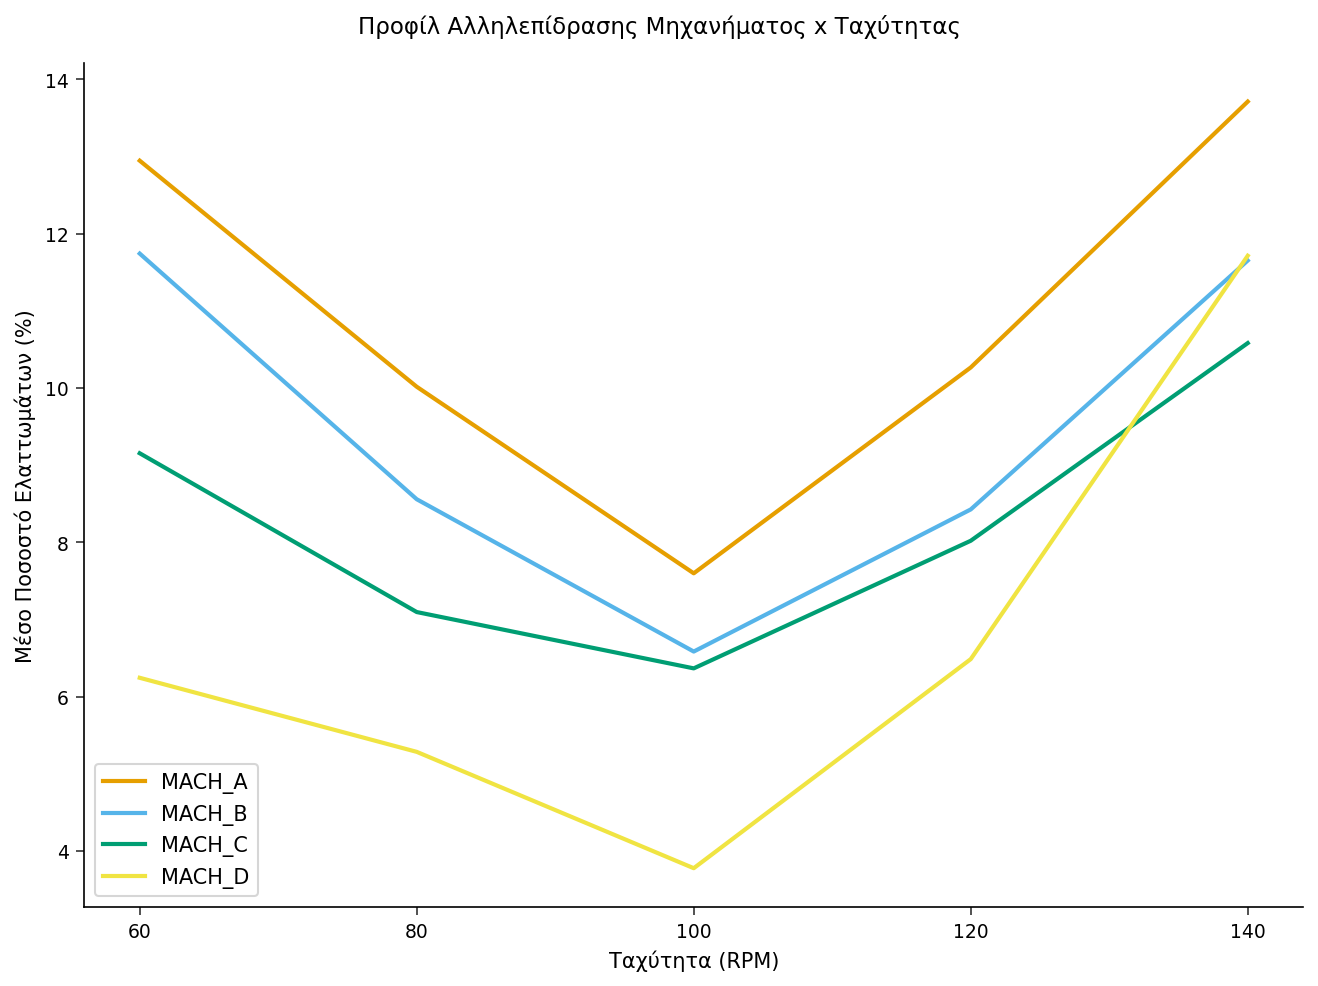

In [3]:
/* --------------------------------------------------------
   Γράφημα αλληλεπίδρασης: μέσο ποσοστό ελαττωμάτων ανά ταχύτητα και μηχάνημα
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=work.molding_experiment NOPRINT;
    ΚΛΑΣΗ machine speed;
    ΜΕΤΑΒΛΗΤΗ defect_rate;
    ΕΞΟΔΟΣ out=work.cell_means mean=mean_defect;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.cell_means(ΟΠΟΥ=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS ΕΤΙΚΕΤΑ='Ταχύτητα (RPM)' VALUES=(60 80 100 120 140);
    YAXIS ΕΤΙΚΕΤΑ='Μέσο Ποσοστό Ελαττωμάτων (%)';
    TITLE 'Προφίλ Αλληλεπίδρασης Μηχανήματος x Ταχύτητας';
ΕΚΤΕΛΕΣΗ;


---

                         Ποσοστό Ελαττωμάτων και Αντοχή σε Εφελκυσμό ανά Μηχάνημα και Ταχύτητα                          

                        The Mixed Procedure                         
                         Model Information                          

Item                                                           Value
-------------------------  -----------------------------------------
Dependent Variable                           Ποσοστό Ελαττωμάτων (%)
Estimation Method                                               REML
Degrees of Freedom Method                              Kenward-Roger
Number of Observations                                           100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

            Type III Tests of Fixed Effects             

Effect              Num DF    Den DF   F Value    Pr > F
----------------  --------  --------  --------  --------


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


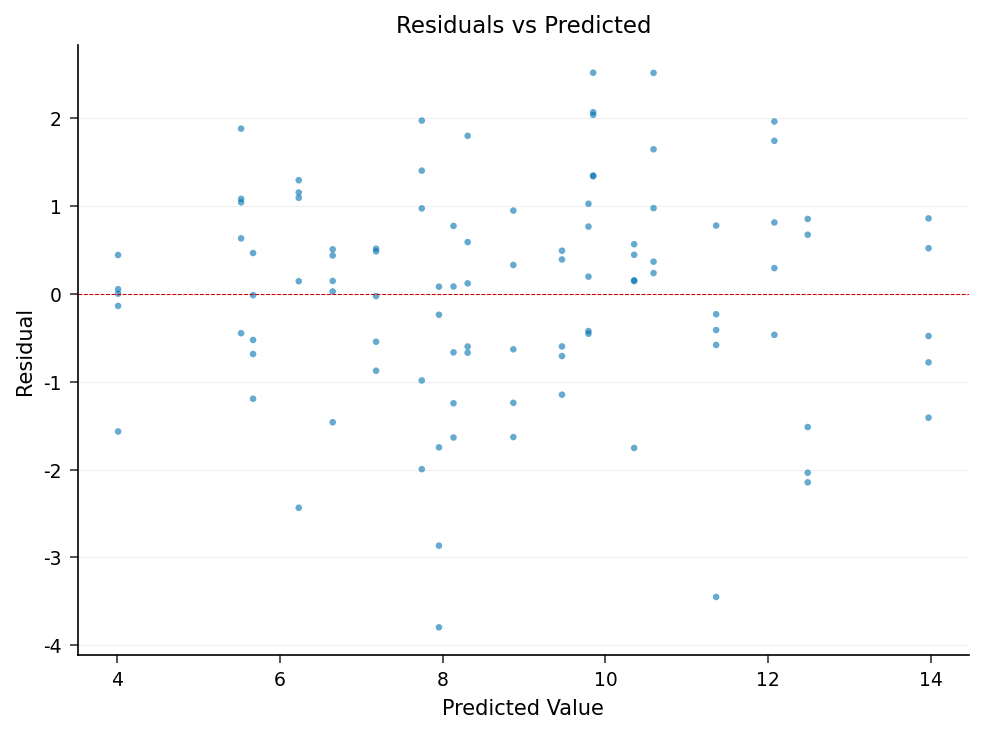

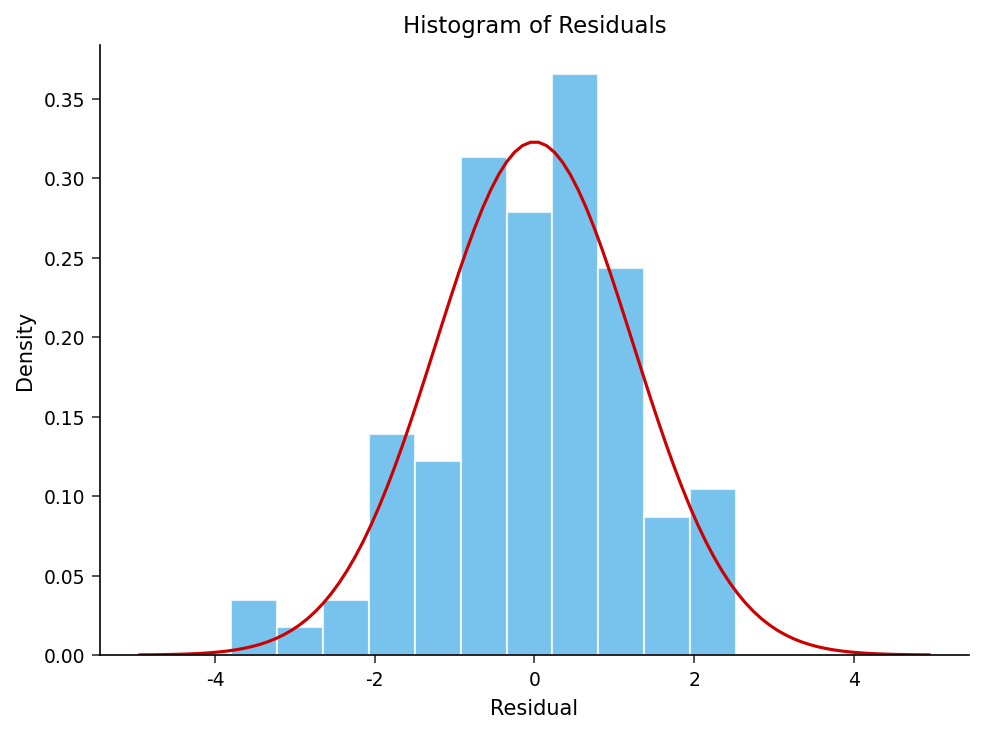

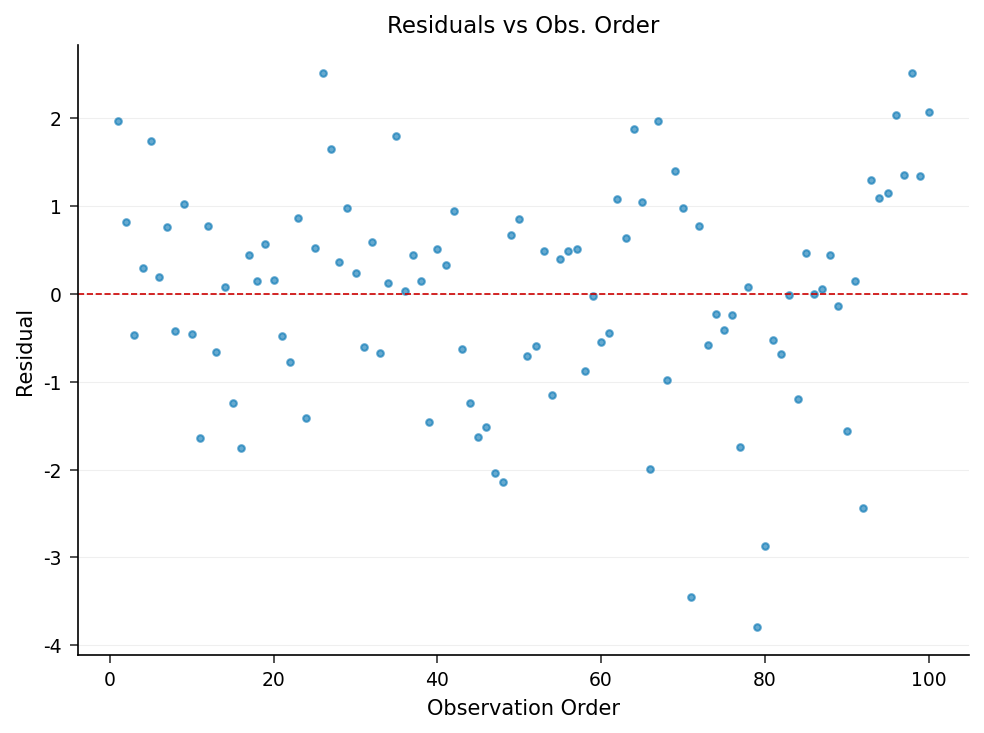

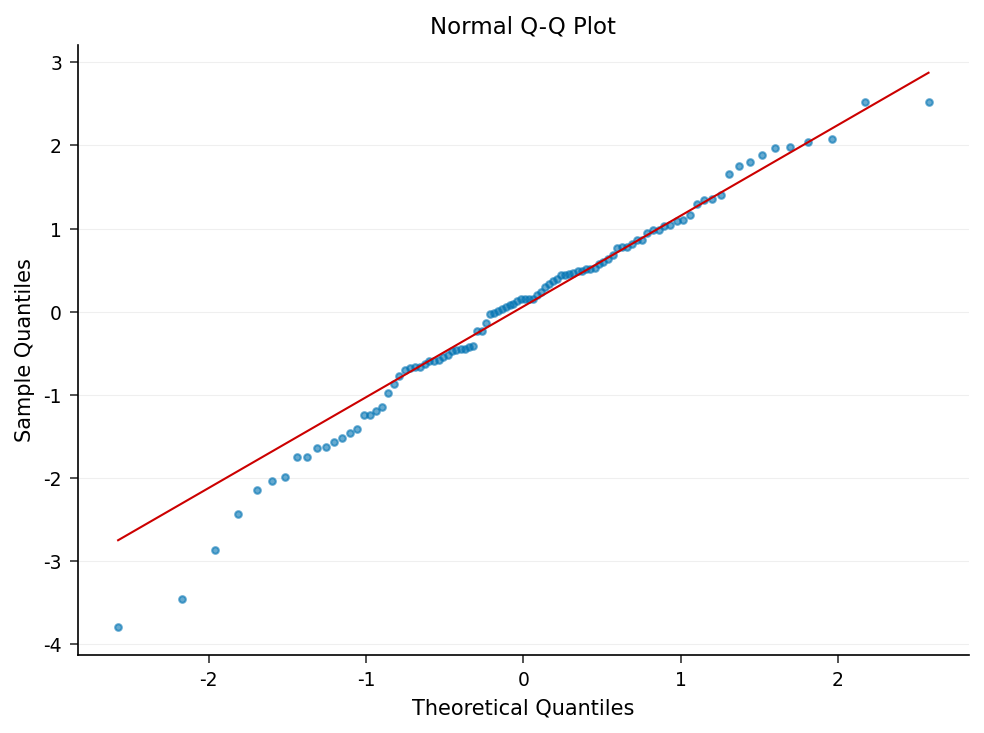

In [4]:
/* --------------------------------------------------------
   Ανάλυση μεικτού μοντέλου split-plot
   Το μηχάνημα είναι τυχαίο (σφάλμα κύριου τεμαχίου)
   Η ταχύτητα είναι σταθερή (παράγοντας υποτεμαχίου)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ MIXED ΔΕΔΟΜΕΝΑ=work.molding_experiment METHOD=reml;
    ΚΛΑΣΗ machine speed_label;
    ΜΟΝΤΕΛΟ defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    ΕΤΙΚΕΤΑ machine='Μηχάνημα' speed_label='Ταχύτητα' defect_rate='Ποσοστό Ελαττωμάτων (%)';
    TITLE 'Ανάλυση Split-Plot: Επίδραση Ταχύτητας στο Ποσοστό Ελαττωμάτων';
ΕΚΤΕΛΕΣΗ;


In [5]:
/* --------------------------------------------------------
   Εντοπισμός βέλτιστης ρύθμισης ταχύτητας
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=work.speed_lsmeans;
    ΚΑΤΑ ESTIMATE;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.optimal_speed;
    ΟΡΙΣΜΟΣ work.speed_lsmeans(obs=1);
    ΚΡΑΤΗΣΗ speed_label ESTIMATE stderr LOWER UPPER;
    ΕΤΙΚΕΤΑ speed_label = 'Βέλτιστη Ταχύτητα'
          ESTIMATE = 'Μέση Τιμή LS Ποσοστού Ελαττωμάτων'
          LOWER = '95% ΔΕ Κάτω Όριο'
          UPPER = '95% ΔΕ Άνω Όριο';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=work.optimal_speed noobs ΕΤΙΚΕΤΑ;
    TITLE 'Συνιστώμενη Ταχύτητα Λειτουργίας για Ελάχιστο Ποσοστό Ελαττωμάτων';
ΕΚΤΕΛΕΣΗ;


                           Συνιστώμενη Ταχύτητα Λειτουργίας για Ελάχιστο Ποσοστό Ελαττωμάτων                            

                Βέλτιστη Ταχύτητα                             Μέση Τιμή LS Ποσοστού Ελαττωμάτων  StdErr            95% ΔΕ Κάτω Όριο           95% ΔΕ Άνω Όριο
                                .                                                         6.081  0.9266                      3.3645                    8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Αποσύνθεση συνιστωσών διακύμανσης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=work.split_covparms noobs;
    TITLE 'Συνιστώσες Διακύμανσης: Μηχάνημα έναντι Υπολοίπου';
ΕΚΤΕΛΕΣΗ;


                                   Συνιστώσες Διακύμανσης: Μηχάνημα έναντι Υπολοίπου                                    

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Ερμηνεία

Το μοντέλο split-plot κατανέμει τη μεταβλητότητα του ποσοστού ελαττωμάτων σε δύο
στρώματα. Η **συνιστώσα διακύμανσης του μηχανήματος (κύριο τεμάχιο) είναι 3.10**
και το **υπόλοιπο (υποτεμάχιο) είναι 1.66**, οπότε οι διαφορές μεταξύ
μηχανημάτων αντιπροσωπεύουν περίπου **65%** της συνολικής διακύμανσης
(3.10 / (3.10 + 1.66)). Αυτό το μεγάλο ποσοστό μεταξύ μηχανημάτων
επιβεβαιώνει ότι το μηχάνημα είναι μια πραγματική πηγή μεταβλητότητας της
διεργασίας και ότι ο σχεδιασμός split-plot - αντί για μια πλήρως
τυχαιοποιημένη ανάλυση - είναι το σωστό πλαίσιο.

Ο έλεγχος Τύπου III της σταθερής επίδρασης της ταχύτητας είναι ιδιαίτερα
σημαντικός: **F(4, 92) = 60.26, p < .0001**, οπότε η ρύθμιση RPM επηρεάζει
έντονα το ποσοστό ελαττωμάτων. Οι ελαχίστου τετραγώνου μέσοι (LS-means)
σχηματίζουν μια σαφή τετραγωνική απόκριση με ελάχιστο στη μεσαία ταχύτητα:

| Ταχύτητα | Μέσο LS ποσοστό ελαττωμάτων (%) | 95% ΔΕ |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Οι προσαρμοσμένες κατά Tukey ανά ζεύγη συγκρίσεις δείχνουν ότι τα **100 RPM
είναι σημαντικά χαμηλότερα από κάθε άλλη ρύθμιση** (προσαρμοσμένο p <= 0.0009
έναντι 80, 120, 60 και 140 RPM). Οι ρυθμίσεις 80 RPM και 120 RPM βρίσκονται
στη μέση και **δεν** διαφέρουν μεταξύ τους (διαφορά 0.56, προσαρμοσμένο
p = 0.6430), ενώ τα 60 RPM και 140 RPM παράγουν τα υψηλότερα ποσοστά
ελαττωμάτων.

**Σύσταση μηχανικής:** τυποποιήστε την παραγωγή στα **100 RPM** σε όλα τα
τέσσερα μηχανήματα, όπου το μοντέλο εκτιμά το χαμηλότερο ποσοστό ελαττωμάτων
(6.08%). Επειδή η συνιστώσα διακύμανσης του μηχανήματος (3.10) είναι η
κυρίαρχη πηγή μεταβλητότητας, οι επόμενες εργασίες θα πρέπει να στοχεύσουν
στη βαθμονόμηση ανά μηχάνημα - το προφίλ αλληλεπίδρασης δείχνει το MACH_D να
τρέχει σταθερά χαμηλότερα και το MACH_A υψηλότερα - ώστε να κλείσει το χάσμα
μεταξύ μηχανημάτων στην επιλεγμένη ρύθμιση των 100 RPM.

---

In [7]:
/* --------------------------------------------------------
   Εξαγωγή αποτελεσμάτων βελτιστοποίησης ταχύτητας για τη μηχανική
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη της <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>